## Obradjeni algoritmi

1. **K-Means** (particioni)
2. **Aglomerativno klasterovanje** (single, complete, average, ward veza)
3. **Bisecting K-Means** (divizivni / top-down pristup)

Koriscene metod lakta, silueta koeficijent, Cilinski-Harbasz i Davies-Bouldin indeks evaluacije. Uporedjeni modeli nad svim atributima i nad razlicitim redukovanim skupovima atributa.

## Cilj klasterovanja

Grupisati tim-sezone (svaki objekat je jedan tim u jednoj sezoni) na osnovu prosecnih statistika po utakmici (napad, odbrana, procenat pobeda) i otkriti tipove timova (npr. ofanzivno orijentisani timovi, defanzivni timovi, dominantni/slabi timovi, razliciti periodi igre itd).

In [1]:
# Uvoz biblioteka
# Osnovne biblioteke
import os
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering, BisectingKMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, adjusted_rand_score

# SciPy
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
    HAS_SNS = True
except Exception:
    HAS_SNS = False

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)
np.random.seed(42)
RANDOM_STATE = 42
plt.rcParams["figure.figsize"] = (9, 5)

In [3]:
# SQLite
import kagglehub

DB_PATH = ""

dataset_dir = kagglehub.dataset_download("wyattowalsh/basketball")
print("Skup preuzet u:", dataset_dir)
for root, _, files in os.walk(dataset_dir):
    for f in files:
        if f.endswith(".sqlite"):
            DB_PATH = os.path.join(root, f)
            break

print("Putanja do baze:", DB_PATH)
assert DB_PATH and os.path.exists(DB_PATH), "Baza nije pronadjena!"
conn = sqlite3.connect(DB_PATH)

/home/p4st3/ip2_projekat/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 697M/697M [00:24<00:00, 29.9MB/s] 

Extracting files...


Skup preuzet u: /home/p4st3/.cache/kagglehub/datasets/wyattowalsh/basketball/versions/238
Putanja do baze: /home/p4st3/.cache/kagglehub/datasets/wyattowalsh/basketball/versions/238/nba.sqlite


In [4]:
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", conn)["name"].tolist()
print("Broj tabela u bazi:", len(tables), "\n")
info = []
for t in tables:
    try:
        n = pd.read_sql(f'SELECT COUNT(*) AS n FROM "{t}"', conn)["n"][0]
    except Exception:
        n = None
    info.append((t, n))

display(pd.DataFrame(info, columns=["tabela", "broj_slogova"]).sort_values("broj_slogova", ascending=False, na_position="last"))

Broj tabela u bazi: 16 



,tabela,broj_slogova
10,play_by_play,13592899
6,inactive_players,110191
8,officials,70971
3,game,65698
5,game_summary,58110
4,game_info,58053
7,line_score,58053
9,other_stats,28271
2,draft_history,8257
11,player,4815


In [5]:
game_tbl = next((t for t in tables if t.lower() == "game"), None)
assert game_tbl is not None, "Tabela 'Game' nije pronadjena u bazi."
print("Koristimo tabelu:", game_tbl)

game = pd.read_sql(f'SELECT * FROM "{game_tbl}"', conn)
game.columns = [c.upper() for c in game.columns]
print("Dimenzije Game tabele:", game.shape)
print("\nPrimer kolona:", list(game.columns)[:20], "...")
game.head(3)

Koristimo tabelu: game
Dimenzije Game tabele: (65698, 55)

Primer kolona: ['SEASON_ID', 'TEAM_ID_HOME', 'TEAM_ABBREVIATION_HOME', 'TEAM_NAME_HOME', 'GAME_ID', 'GAME_DATE', 'MATCHUP_HOME', 'WL_HOME', 'MIN', 'FGM_HOME', 'FGA_HOME', 'FG_PCT_HOME', 'FG3M_HOME', 'FG3A_HOME', 'FG3_PCT_HOME', 'FTM_HOME', 'FTA_HOME', 'FT_PCT_HOME', 'OREB_HOME', 'DREB_HOME'] ...


,SEASON_ID,TEAM_ID_HOME,TEAM_ABBREVIATION_HOME,TEAM_NAME_HOME,GAME_ID,GAME_DATE,MATCHUP_HOME,WL_HOME,MIN,FGM_HOME,FGA_HOME,FG_PCT_HOME,FG3M_HOME,FG3A_HOME,FG3_PCT_HOME,FTM_HOME,FTA_HOME,FT_PCT_HOME,OREB_HOME,DREB_HOME,REB_HOME,AST_HOME,STL_HOME,BLK_HOME,TOV_HOME,PF_HOME,PTS_HOME,PLUS_MINUS_HOME,VIDEO_AVAILABLE_HOME,TEAM_ID_AWAY,TEAM_ABBREVIATION_AWAY,TEAM_NAME_AWAY,MATCHUP_AWAY,WL_AWAY,FGM_AWAY,FGA_AWAY,FG_PCT_AWAY,FG3M_AWAY,FG3A_AWAY,FG3_PCT_AWAY,FTM_AWAY,FTA_AWAY,FT_PCT_AWAY,OREB_AWAY,DREB_AWAY,REB_AWAY,AST_AWAY,STL_AWAY,BLK_AWAY,TOV_AWAY,PF_AWAY,PTS_AWAY,PLUS_MINUS_AWAY,VIDEO_AVAILABLE_AWAY,SEASON_TYPE
0,21946,1610610035,HUS,Toronto Huskies,0024600001,1946-11-01 00:00:00,HUS vs. NYK,L,0,25.0,NaN,NaN,NaN,NaN,NaN,16.0,29.0,0.552,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,66.0,-2,0,1610612752,NYK,New York Knicks,NYK @ HUS,W,24.0,NaN,NaN,NaN,NaN,NaN,20.0,26.0,0.769,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68.0,2,0,Regular Season
1,21946,1610610034,BOM,St. Louis Bombers,0024600003,1946-11-02 00:00:00,BOM vs. PIT,W,0,20.0,59.0,0.339,NaN,NaN,NaN,16.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.0,56.0,5,0,1610610031,PIT,Pittsburgh Ironmen,PIT @ BOM,L,16.0,72.0,0.222,NaN,NaN,NaN,19.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.0,51.0,-5,0,Regular Season
2,21946,1610610032,PRO,Providence Steamrollers,0024600002,1946-11-02 00:00:00,PRO vs. BOS,W,0,21.0,NaN,NaN,NaN,NaN,NaN,17.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,59.0,6,0,1610612738,BOS,Boston Celtics,BOS @ PRO,L,21.0,NaN,NaN,NaN,NaN,NaN,11.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,53.0,-6,0,Regular Season


Tabela Game sadrzi po jednu vrstu za svaku utakmicu sa statistikom domacina (\*_HOME) i gosta (\*_AWAY). Da bismo dobili skup nad kojim cemo raditi klasterovanje, potrebno je:

1. Razdvojiti svaku utakmicu na perspektivu jednog tima, odnosno svaka utakmica daje dve vrste: jednu iz ugla domacina, jednu iz ugla gosta.
2. Agregirati po kljucu (tim, sezona) - racunamo prosecne vrednosti po utakmici za svaki pokazatelj, kao i procenat pobeda i broj odigranih utakmica

Rezultat: svaki objekat je jedna tim-sezona opisana ofanzivnim i defanzivnim prosecnim pokazateljima.

In [6]:
import re

def extract_year(s):
    m = re.search(r"(19|20)\d{2}", str(s))
    return float(m.group()) if m else np.nan

sid = game["SEASON_ID"].astype(str) if "SEASON_ID" in game.columns else None
if sid is not None:
    # SEASON_ID oblika '22018': prvi karakter je tip sezone (2 = regularna sezona)
    game["SEASON_TYPE"] = sid.str[0]

game["SEASON_YEAR"] = sid.map(extract_year)

mask = game["SEASON_TYPE"] == "2"
if mask.sum() > 0.3 * len(game):
    before = len(game)
    game = game[mask].copy()
    print(f"Filtrirano na regularu sezonu: {before} -> {len(game)} utakmica")

game = game[game["SEASON_YEAR"].notna()].copy()
print("Raspon sezona:", int(game['SEASON_YEAR'].min()), "-", int(game['SEASON_YEAR'].max()))

Filtrirano na regularu sezonu: 65698 -> 60192 utakmica
Raspon sezona: 1946 - 2022


In [7]:
home_bases = {c[:-5] for c in game.columns if c.endswith("_HOME")}
away_bases = {c[:-5] for c in game.columns if c.endswith("_AWAY")}

EXCLUDE = {"TEAM_ID", "TEAM_ABBREVIATION", "TEAM_NAME", "MATCHUP", "WL", "VIDEO_AVAILABLE"}
stat_bases = sorted(b for b in (home_bases & away_bases) if b not in EXCLUDE)
print("Statisticki pokazatelji (baze):")
print(stat_bases)

Statisticki pokazatelji (baze):
['AST', 'BLK', 'DREB', 'FG3A', 'FG3M', 'FG3_PCT', 'FGA', 'FGM', 'FG_PCT', 'FTA', 'FTM', 'FT_PCT', 'OREB', 'PF', 'PLUS_MINUS', 'PTS', 'REB', 'STL', 'TOV']


In [8]:
# Razdvajanje utakmica na perspektivu jednog tima
def side_frame(side, opp):
    d = pd.DataFrame()
    d["SEASON_YEAR"] = game["SEASON_YEAR"].values
    d["TEAM_ID"] = game[f"TEAM_ID_{side}"].values
    d["TEAM_NAME"] = game[f"TEAM_NAME_{side}"].values
    d["WL"] = game[f"WL_{side}"].values
    for b in stat_bases:
        d[b] = pd.to_numeric(game[f"{b}_{side}"], errors="coerce").values # napad
        d[b + "_ALLOWED"] = pd.to_numeric(game[f"{b}_{opp}"], errors="coerce").values # odbrana
    return d

long_df = pd.concat([side_frame("HOME", "AWAY"), side_frame("AWAY", "HOME")], ignore_index=True)

# PLUS_MINUS_ALLOWED je negacije od PLUS_MINUS -> redudantno
long_df = long_df.drop(columns=[c for c in ["PLUS_MINUS_ALLOWED"] if c in long_df.columns])

# indikator pobede
long_df["WIN"] = (long_df["WL"] == "W").astype(float)
print("Long format (tim po utakmici):", long_df.shape)
long_df.head(3)

Long format (tim po utakmici): (120384, 42)


,SEASON_YEAR,TEAM_ID,TEAM_NAME,WL,AST,AST_ALLOWED,BLK,BLK_ALLOWED,DREB,DREB_ALLOWED,FG3A,FG3A_ALLOWED,FG3M,FG3M_ALLOWED,FG3_PCT,FG3_PCT_ALLOWED,FGA,FGA_ALLOWED,FGM,FGM_ALLOWED,FG_PCT,FG_PCT_ALLOWED,FTA,FTA_ALLOWED,FTM,FTM_ALLOWED,FT_PCT,FT_PCT_ALLOWED,OREB,OREB_ALLOWED,PF,PF_ALLOWED,PLUS_MINUS,PTS,PTS_ALLOWED,REB,REB_ALLOWED,STL,STL_ALLOWED,TOV,TOV_ALLOWED,WIN
0,1946.0,1610610035,Toronto Huskies,L,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.0,24.0,NaN,NaN,29.0,26.0,16.0,20.0,0.552,0.769,NaN,NaN,NaN,NaN,-2,66.0,68.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1,1946.0,1610610034,St. Louis Bombers,W,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,59.0,72.0,20.0,16.0,0.339,0.222,NaN,NaN,16.0,19.0,NaN,NaN,NaN,NaN,21.0,25.0,5,56.0,51.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0
2,1946.0,1610610032,Providence Steamrollers,W,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.0,21.0,NaN,NaN,NaN,NaN,17.0,11.0,NaN,NaN,NaN,NaN,NaN,NaN,6,59.0,53.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0


In [9]:
# agregacija po (TEAM_ID, SEASON_YEAR), prosek po utakmici
stat_cols = [c for c in long_df.columns if c not in {"SEASON_YEAR", "TEAM_ID", "TEAM_NAME", "WL", "WIN"}]

grp = long_df.groupby(["TEAM_ID", "SEASON_YEAR"])
team_season = grp[stat_cols].mean()
team_season["WIN_PCT"] = grp["WIN"].mean()
team_season["GP"] = grp.size() # broj odigranih utakmica

# najcesci naziv u okviru tim-sezone radi lakse interpretacije
team_name = grp["TEAM_NAME"].agg(lambda s: s.mode().iloc[0] if not s.mode().empty else s.iloc[0])
team_season["TEAM_NAME"] = team_name

team_season = team_season.reset_index()

# uklanjamo delove sa premalo utakmica
before = len(team_season)
team_season = team_season[team_season["GP"] >= 20].reset_index(drop=True)
print(f"Tim-sezona nakon filtriranja (GP>=20): {before} -> {len(team_season)}")

# citljiva oznaka
team_season["LABEL"] = team_season["TEAM_NAME"] + " " + team_season["SEASON_YEAR"].astype(int).astype(str)
team_season.head()

Tim-sezona nakon filtriranja (GP>=20): 1519 -> 1519


,TEAM_ID,SEASON_YEAR,AST,AST_ALLOWED,BLK,BLK_ALLOWED,DREB,DREB_ALLOWED,FG3A,FG3A_ALLOWED,FG3M,FG3M_ALLOWED,FG3_PCT,FG3_PCT_ALLOWED,FGA,FGA_ALLOWED,FGM,FGM_ALLOWED,FG_PCT,FG_PCT_ALLOWED,FTA,FTA_ALLOWED,FTM,FTM_ALLOWED,FT_PCT,FT_PCT_ALLOWED,OREB,OREB_ALLOWED,PF,PF_ALLOWED,PLUS_MINUS,PTS,PTS_ALLOWED,REB,REB_ALLOWED,STL,STL_ALLOWED,TOV,TOV_ALLOWED,WIN_PCT,GP,TEAM_NAME,LABEL
0,1610610023,1949.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.359375,29.234375,NaN,NaN,36.590164,35.426230,26.609375,25.062500,0.727148,0.715295,NaN,NaN,25.125,29.125,3.796875,87.328125,83.531250,NaN,NaN,NaN,NaN,NaN,NaN,0.578125,64,Anderson Packers,Anderson Packers 1949
1,1610610024,1947.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26.851064,25.531915,NaN,NaN,29.452381,26.880952,20.260870,18.978723,0.704561,0.693214,NaN,NaN,20.500,25.000,3.693878,74.285714,70.591837,NaN,NaN,NaN,NaN,NaN,NaN,0.571429,49,Baltimore Bullets,Baltimore Bullets 1947
2,1610610024,1948.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.933333,29.000000,NaN,NaN,34.220339,34.576271,25.750000,24.233333,0.756797,0.703492,NaN,NaN,NaN,NaN,1.383333,83.616667,82.233333,NaN,NaN,NaN,NaN,NaN,NaN,0.483333,60,Baltimore Bullets,Baltimore Bullets 1948
3,1610610024,1949.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.191176,27.911765,NaN,NaN,31.397059,31.308824,22.750000,22.897059,0.722765,0.732794,NaN,NaN,28.400,24.800,-5.588235,73.132353,78.720588,NaN,NaN,NaN,NaN,NaN,NaN,0.367647,68,Baltimore Bullets,Baltimore Bullets 1949
4,1610610024,1950.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.600000,30.061538,NaN,NaN,30.569231,32.753846,22.846154,24.353846,0.747431,0.746708,NaN,NaN,NaN,NaN,-2.287879,82.030303,84.318182,NaN,NaN,NaN,NaN,NaN,NaN,0.363636,66,Baltimore Bullets,Baltimore Bullets 1950


In [10]:
# cuvanje pocetne verzije
os.makedirs("data", exist_ok=True)
team_season.to_csv("data/tim_sezone_pocetni.csv", index=False)
print("Sacuvano: data/tim_sezone_pocetni.csv", team_season.shape)

Sacuvano: data/tim_sezone_pocetni.csv (1519, 43)


In [11]:
# analiza podataka
print("Dimenzije skupa:", team_season.shape)
print("\nBroj razlicitih timova:", team_season['TEAM_ID'].nunique())
print("Raspon sezona:", int(team_season['SEASON_YEAR'].min()), "-", int(team_season['SEASON_YEAR'].max()))
# atributi koje koristimo za klasterovanje
feature_cols = [c for c in team_season.columns if c not in {"TEAM_ID", "SEASON_YEAR", "GP", "TEAM_NAME", "LABEL"}]
print("\nBroj atributa za klasterovanje:", len(feature_cols))
print(feature_cols)

Dimenzije skupa: (1519, 43)

Broj razlicitih timova: 45
Raspon sezona: 1946 - 2022

Broj atributa za klasterovanje: 38
['AST', 'AST_ALLOWED', 'BLK', 'BLK_ALLOWED', 'DREB', 'DREB_ALLOWED', 'FG3A', 'FG3A_ALLOWED', 'FG3M', 'FG3M_ALLOWED', 'FG3_PCT', 'FG3_PCT_ALLOWED', 'FGA', 'FGA_ALLOWED', 'FGM', 'FGM_ALLOWED', 'FG_PCT', 'FG_PCT_ALLOWED', 'FTA', 'FTA_ALLOWED', 'FTM', 'FTM_ALLOWED', 'FT_PCT', 'FT_PCT_ALLOWED', 'OREB', 'OREB_ALLOWED', 'PF', 'PF_ALLOWED', 'PLUS_MINUS', 'PTS', 'PTS_ALLOWED', 'REB', 'REB_ALLOWED', 'STL', 'STL_ALLOWED', 'TOV', 'TOV_ALLOWED', 'WIN_PCT']


In [12]:
team_season[feature_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
AST,1190.0,22.990083,3.246521,0.000000,21.121951,22.939024,25.024390,33.000000
AST_ALLOWED,1190.0,23.024390,3.196923,0.000000,21.280122,23.182927,24.963415,35.000000
BLK,1149.0,5.028666,0.999157,2.000000,4.341463,4.939024,5.560976,10.000000
BLK_ALLOWED,1149.0,5.152373,1.087151,2.987805,4.536585,5.024390,5.546875,15.000000
DREB,1079.0,30.717051,2.507462,19.000000,29.036585,30.390244,32.310976,42.232877
DREB_ALLOWED,1080.0,30.730048,2.599523,8.000000,28.878049,30.469512,32.500000,37.695122
FG3A,1153.0,16.505161,9.854207,0.000000,9.134146,15.487805,22.304878,45.378049
FG3A_ALLOWED,1153.0,16.417828,9.573853,0.000000,9.109756,15.695122,20.853659,40.585366
FG3M,1198.0,5.616668,3.734210,0.000000,2.685976,5.280488,7.862805,16.736111
FG3M_ALLOWED,1198.0,5.617020,3.574596,0.000000,2.588415,5.414634,7.314024,14.833333


In [13]:
# nedostajuce vrednosti
miss = team_season[feature_cols].isna().sum()
miss = miss[miss > 0]
if len(miss):
    print("Kolone sa nedostajucim vrednostima:")
    display(miss.to_frame("broj_nedostajucih"))
else:
    print("Nema nedostajucih vrednosti!")

Kolone sa nedostajucim vrednostima:


,broj_nedostajucih
AST,329
AST_ALLOWED,329
BLK,370
BLK_ALLOWED,370
DREB,440
DREB_ALLOWED,439
FG3A,366
FG3A_ALLOWED,366
FG3M,321
FG3M_ALLOWED,321


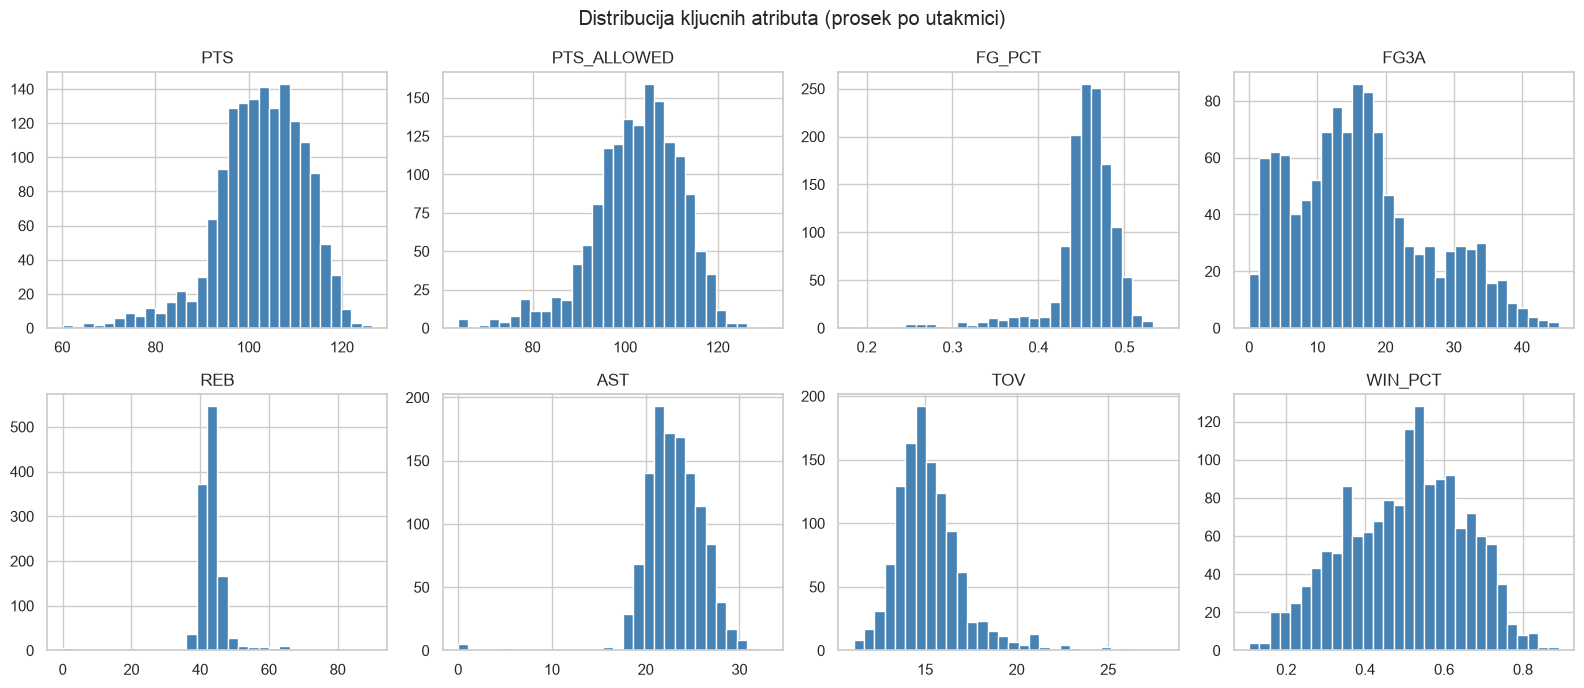

In [14]:
key = [c for c in ["PTS", "PTS_ALLOWED", "FG_PCT", "FG3A", "REB", "AST", "TOV", "WIN_PCT"] if c in feature_cols]
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, c in zip(axes.ravel(), key):
    ax.hist(team_season[c].dropna(), bins=30, color="steelblue", edgecolor="white")
    ax.set_title(c)
plt.suptitle("Distribucija kljucnih atributa (prosek po utakmici)")
plt.tight_layout()
plt.show()

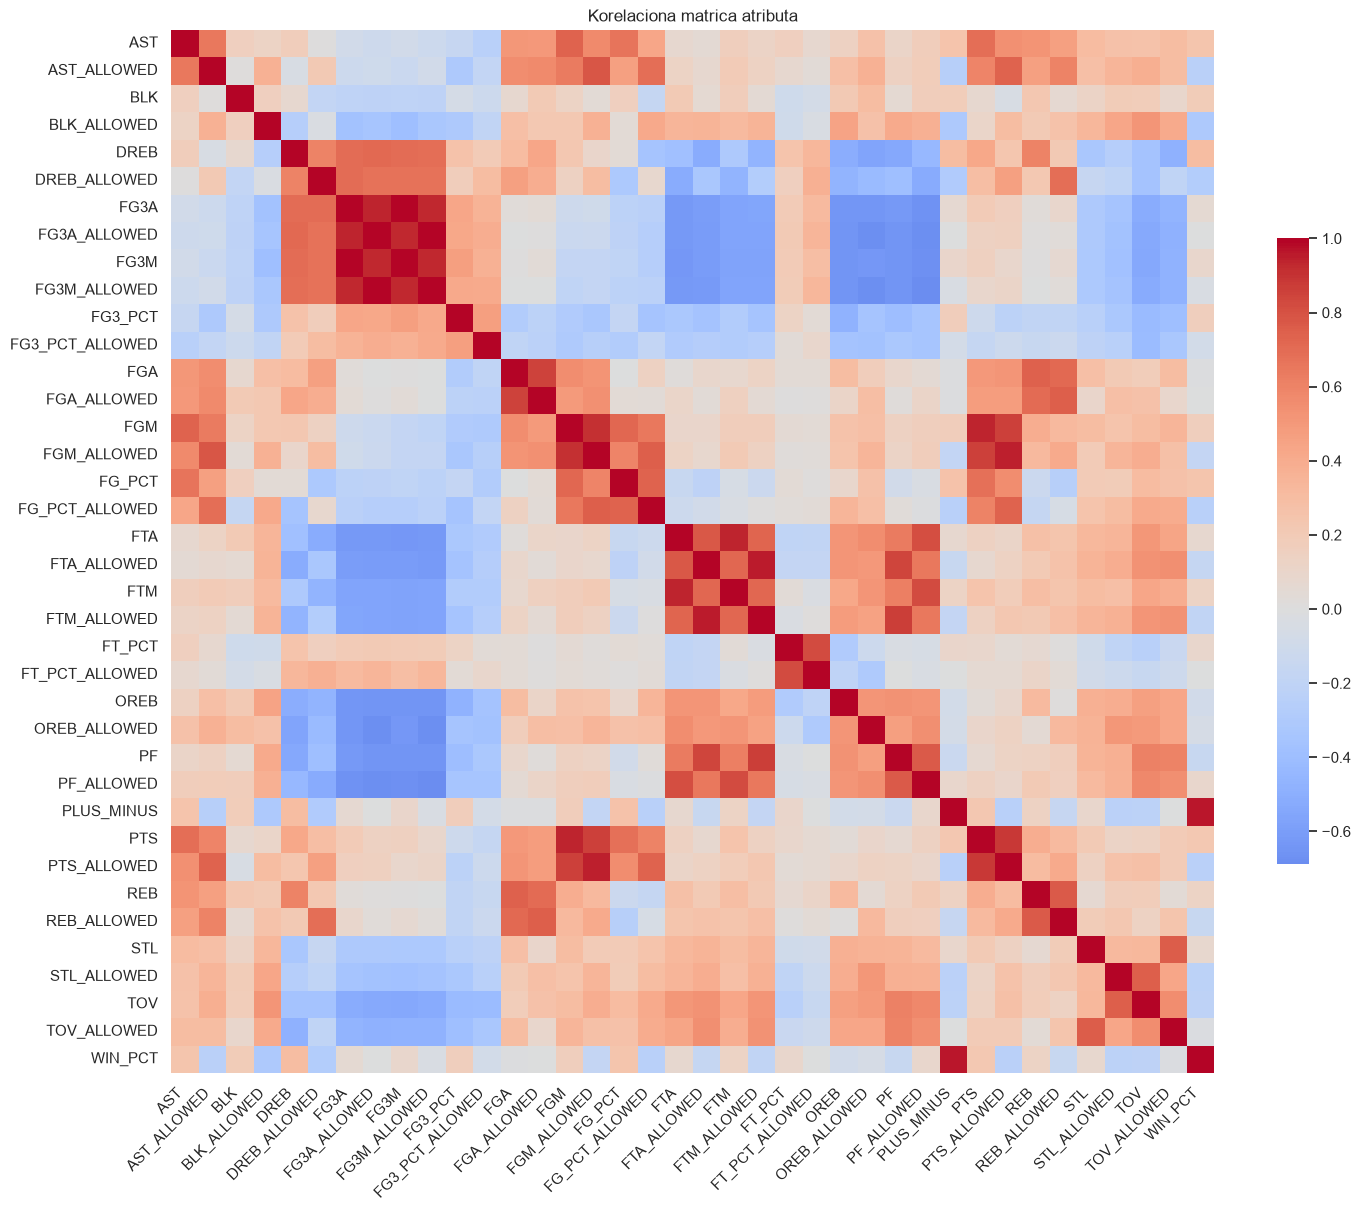

In [15]:
# korelaciona matrica
corr = team_season[feature_cols].corr()
fig, ax = plt.subplots(figsize=(14, 12), constrained_layout=True)
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    cbar_kws={"shrink": 0.6},
    xticklabels=True,
    yticklabels=True,
    ax=ax,
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.set_title("Korelaciona matrica atributa")
plt.show()

## Pretprocesiranje

- Obrada nedostajucih vrednosti
- Skaliranje

In [16]:
X_df = team_season[feature_cols].copy()

# uzimamo medijanu kolone
na_before = int(X_df.isna().sum().sum())
X_df = X_df.fillna(X_df.median(numeric_only=True))
print("Popunjeno nedostajucih vrednosti medijanom:", na_before)

# standardizacija
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_df)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols, index=team_season.index)
print("Oblik skalirane matrice:", X_scaled.shape)
print("Prosek nakon skaliranja:", np.round(X_scaled.mean(axis=0)[:5], 3),
      "| Std:", np.round(X_scaled.std(axis=0)[:5], 3))

Popunjeno nedostajucih vrednosti medijanom: 8367
Oblik skalirane matrice: (1519, 38)
Prosek nakon skaliranja: [ 0.  0.  0. -0.  0.] | Std: [1. 1. 1. 1. 1.]


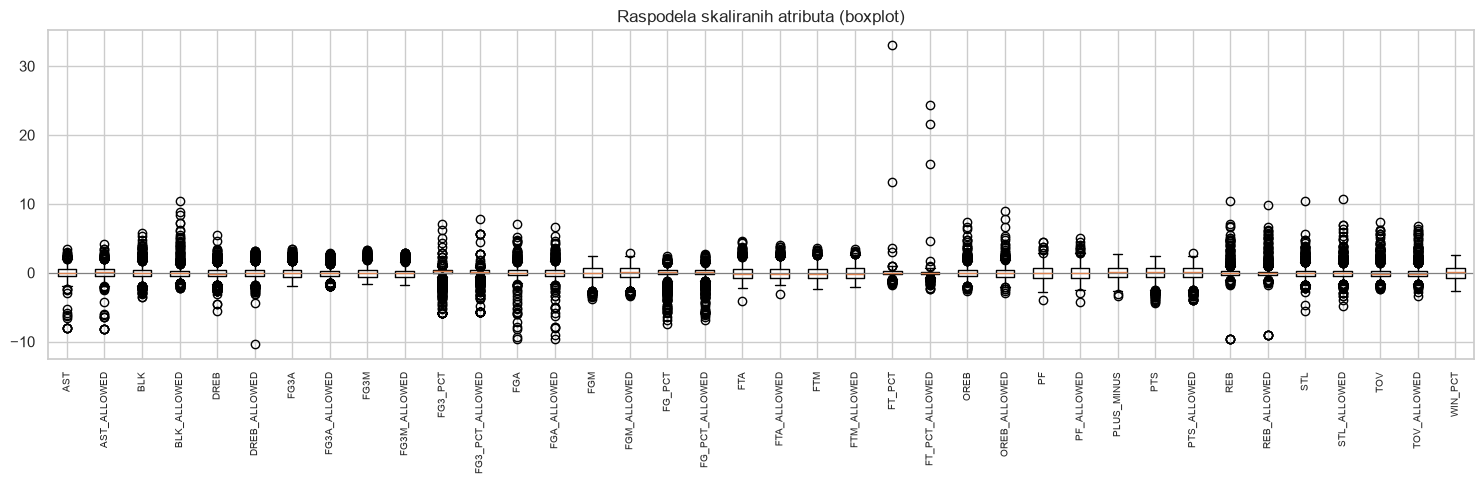

In [17]:
# elementi van granica (zanimljivo za kontekst klasterovanja)
plt.figure(figsize=(15, 5))
plt.boxplot([X_scaled_df[c] for c in feature_cols], showfliers=True)
plt.xticks(range(1, len(feature_cols) + 1), feature_cols, rotation=90, fontsize=7)
plt.axhline(0, color="gray", lw=.8)
plt.title("Raspodela skaliranih atributa (boxplot)")
plt.tight_layout()
plt.show()

In [22]:
# cuvanje pretprocesirane verzije
X_scaled_df.assign(LABEL=team_season["LABEL"].values).to_csv("data/tim_sezone_skalirano.csv", index=False)
print("Sacuvano: data/tim_sezone_skalirano.csv", X_scaled_df.shape)

Sacuvano: data/tim_sezone_skalirano.csv (1519, 38)


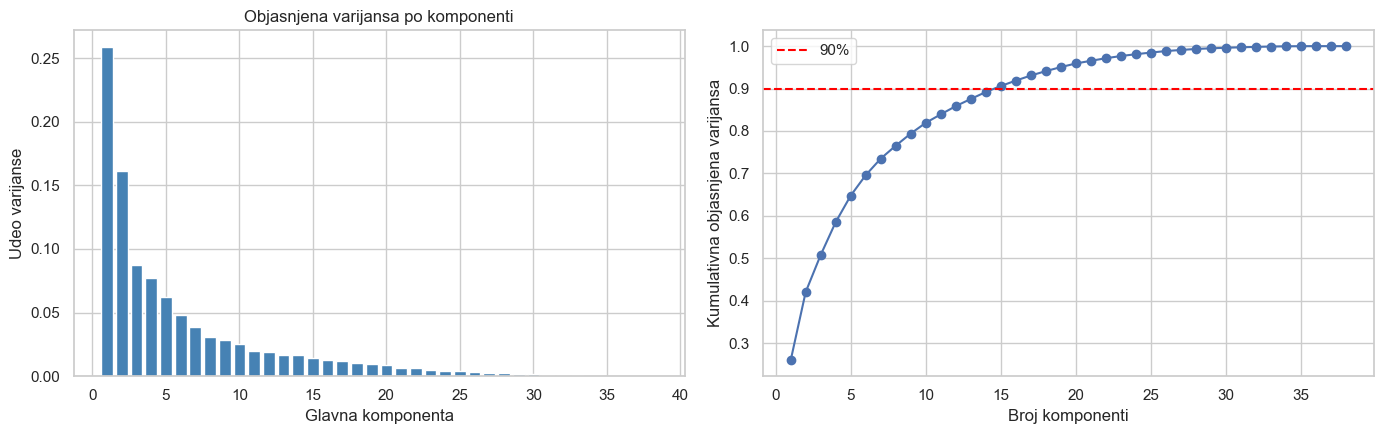

Broj komponenti za >=90% varijanse: 15


In [23]:
# redukcija dimenzionalnosti i vizuelizacija
pca_full = PCA().fit(X_scaled)
expl = pca_full.explained_variance_ratio_
cumsum = np.cumsum(expl)

fix, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].bar(range(1, len(expl) + 1), expl, color="steelblue")
ax[0].set_xlabel("Glavna komponenta")
ax[0].set_ylabel("Udeo varijanse")
ax[0].set_title("Objasnjena varijansa po komponenti")
ax[1].plot(range(1, len(cumsum) + 1), cumsum, marker="o")
ax[1].axhline(0.9, color="red", ls="--", label="90%")
ax[1].set_xlabel("Broj komponenti")
ax[1].set_ylabel("Kumulativna objasnjena varijansa")
ax[1].legend()
plt.tight_layout()
plt.show()

k90 = int(np.argmax(cumsum >= 0.9) + 1)
print(f"Broj komponenti za >=90% varijanse: {k90}")

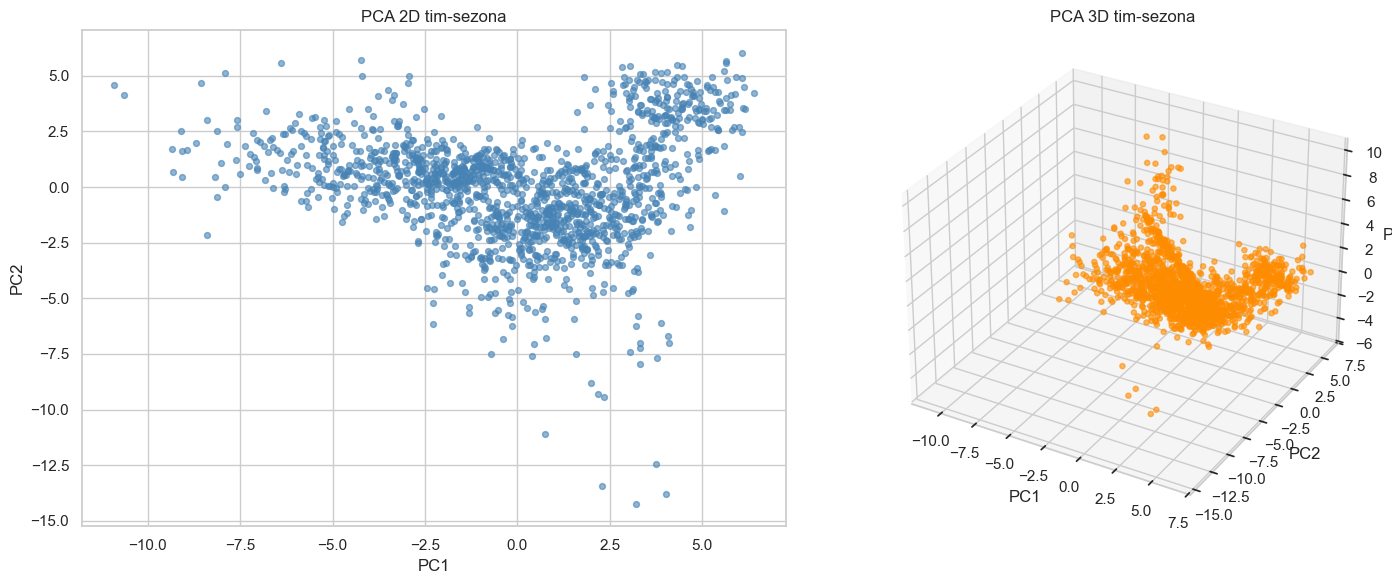

In [24]:
# 2D i 3D projekcija pomocu PCA
pca3 = PCA(n_components=3, random_state=RANDOM_STATE)
X_pca3 = pca3.fit_transform(X_scaled)

fig = plt.figure(figsize=(15, 6))
# 2D
ax1 = fig.add_subplot(1, 2, 1)
ax1.scatter(X_pca3[:,0], X_pca3[:,1], s=18, alpha=.6, color="steelblue")
ax1.set_xlabel("PC1")
ax1.set_ylabel("PC2")
ax1.set_title("PCA 2D tim-sezona")

# 3D
ax2 = fig.add_subplot(1, 2, 2, projection="3d")
ax2.scatter(X_pca3[:, 0], X_pca3[:,1], X_pca3[:,2], s=14, alpha=.6, color="darkorange")
ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")
ax2.set_zlabel("PC3")
ax2.set_title("PCA 3D tim-sezona")

plt.tight_layout()
plt.show()

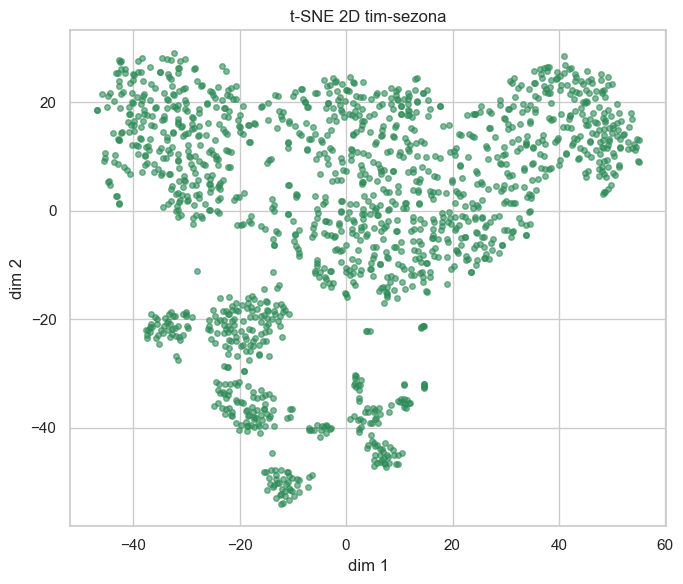

In [25]:
# t-SNE 2D (nelinearno mapiranje)
tsne = TSNE(n_components=2, perplexity=30, init="pca", random_state=RANDOM_STATE)
X_tsne = tsne.fit_transform(X_scaled)
plt.figure(figsize=(7, 6))
plt.scatter(X_tsne[:,0], X_tsne[:,1], s=16, alpha=.6, color="seagreen")
plt.title("t-SNE 2D tim-sezona")
plt.xlabel("dim 1")
plt.ylabel("dim 2")
plt.tight_layout()
plt.show()

## Priprema razlicitih skupova atributa

- Skup A - Svi atributi - pun opis (napad + odbrana + % pobeda)
- Skup B - Ofanzivni (bez _ALLOWED) - ofanzivni profil tima
- Skup C - Efikasnost - manji skup
- Skup D - PCA - prve komponente koje objasnjavaju >=90% varijanse (linearno redukovan skup)

In [26]:
# Skup A
A_all = X_scaled_df.copy()

# Skup B
off_cols = [c for c in feature_cols if not c.endswith("_ALLOWED") and c != "WIN_PCT"]
B_off = X_scaled_df[off_cols].copy()

# Skup C
wanted = ["FG_PCT", "FG3_PCT", "FT_PCT", "FG3A", "AST", "TOV", "OREB", "PTS", "PTS_ALLOWED", "FG_PCT_ALLOWED"]
eff_cols = [c for c in wanted if c in feature_cols]
C_eff = X_scaled_df[eff_cols].copy()

# Skup D
pca_k = PCA(n_components=k90, random_state=RANDOM_STATE)
D_pca = pd.DataFrame(pca_k.fit_transform(X_scaled), columns=[f"PC{i+1}" for i in range(k90)], index=X_scaled_df.index)

feature_sets = {
    "A: svi atributi": A_all,
    "B: ofanzivni": B_off,
    "C: efikasnost": C_eff,
    "D: PCA(>=90%)": D_pca
}

for name, M in feature_sets.items():
    print(f"{name:20s} -> {M.shape[1]} atributa")

A: svi atributi      -> 38 atributa
B: ofanzivni         -> 19 atributa
C: efikasnost        -> 10 atributa
D: PCA(>=90%)        -> 15 atributa


## K-Means

K-Means je particioni algoritam: unapred se zadaje broj klastera K, nasumično se biraju centri (centroidi), pa se iterativno naizmenično (1) svaka tačka dodeljuje najbližem centroidu i (2) centroidi se pomeraju na sredinu svog klastera. Cilj je minimizacija sume kvadrata rastojanja tačaka do centroida.

K-Means++ je poboljšanje kod koga se početni centroidi biraju pametnije (proporcionalno kvadratu udaljenosti od već izabranih), što daje bržu konvergenciju i stabilnije rezultate.

### Izbor broja klastera

Optimalan broj klastera biramo pomoću tri kriterijuma nad skupom A (svi atributi):

- Metod lakta (elbow) - WCSS (inertia) u funkciji od K;
- Silueta koeficijent - što veći, to bolje razdvojeni i gušći klasteri;
- Calinski–Harabasz indeks - odnos međuklasterske i unutarklasterske varijanse (veće = bolje).

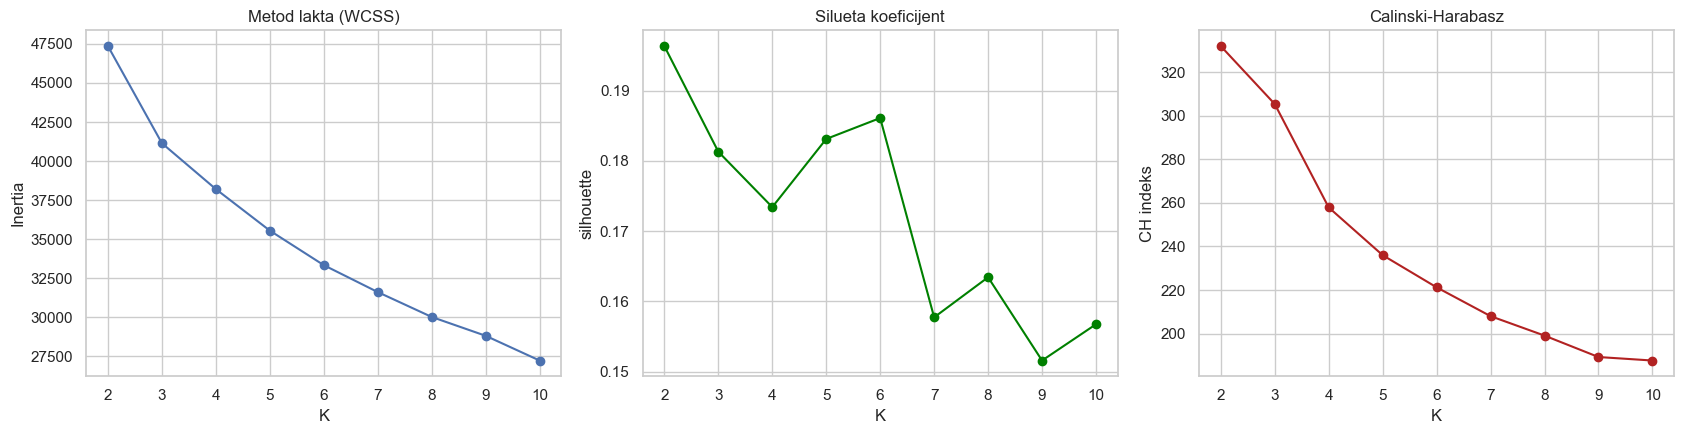

Predlog K po silueti: 2 | po CH: 2


In [27]:
K_range = range(2, 11)
inertia, sil, ch = [], [], []
for k in K_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=20, max_iter=500, random_state=RANDOM_STATE)
    lab = km.fit_predict(A_all.values)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(A_all.values, lab))
    ch.append(calinski_harabasz_score(A_all.values, lab))

fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
ax[0].plot(list(K_range), inertia, marker="o"); ax[0].set_title("Metod lakta (WCSS)")
ax[0].set_xlabel("K")
ax[0].set_ylabel("Inertia")
ax[1].plot(list(K_range), sil, marker="o", color="green")
ax[1].set_title("Silueta koeficijent")
ax[1].set_xlabel("K")
ax[1].set_ylabel("silhouette")
ax[2].plot(list(K_range), ch, marker="o", color="firebrick")
ax[2].set_title("Calinski-Harabasz")
ax[2].set_xlabel("K")
ax[2].set_ylabel("CH indeks")
plt.tight_layout()
plt.show()

best_k = list(K_range)[int(np.argmax(sil))]
print("Predlog K po silueti:", best_k, "| po CH:", list(K_range)[int(np.argmax(ch))])

In [28]:
K = best_k
kmeans = KMeans(n_clusters=K, init="k-means++", n_init=50, max_iter=500, random_state=RANDOM_STATE)
km_labels = kmeans.fit_predict(A_all.values)
team_season["cluster_kmeans"] = km_labels

print(f"K-Means (K={K}) -> velicine klastera:")
print(pd.Series(km_labels).value_counts().sort_index())
print("\nSilueta:", round(silhouette_score(A_all.values, km_labels), 4),
      "| CH:", round(calinski_harabasz_score(A_all.values, km_labels), 1),
      "| DB:", round(davies_bouldin_score(A_all.values, km_labels), 4))

K-Means (K=2) -> velicine klastera:
0    921
1    598
Name: count, dtype: int64

Silueta: 0.1963 | CH: 332.0 | DB: 1.8892


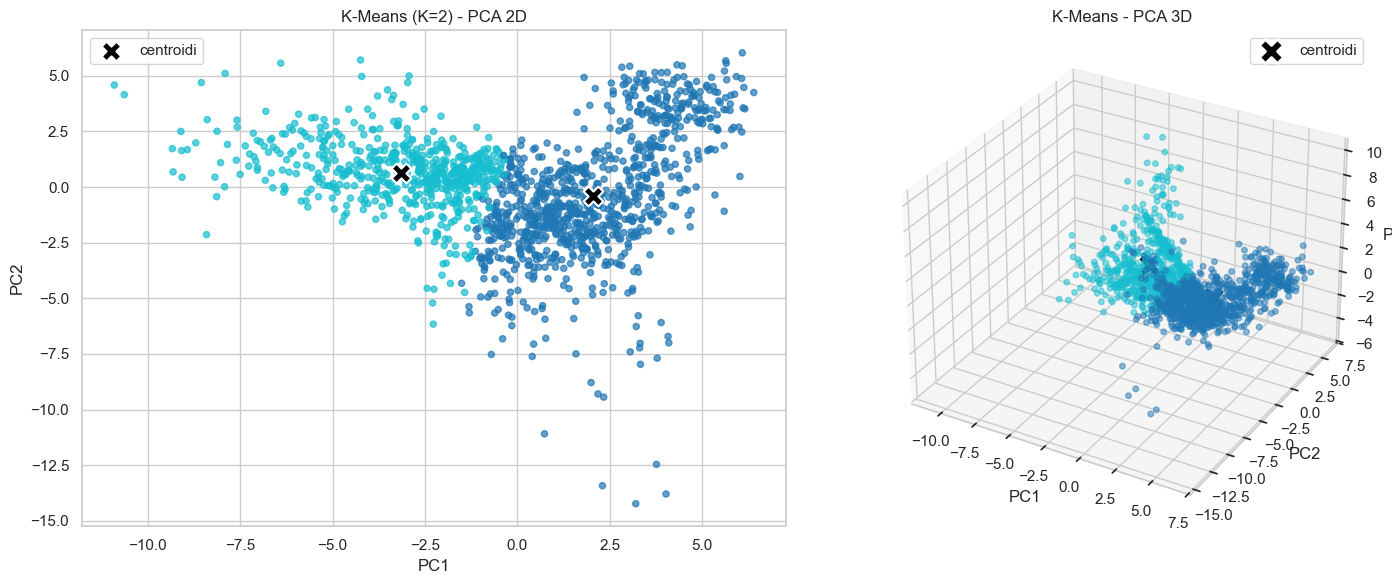

In [30]:
# vizuelizacija u 2D i 3D
centroids_pca = pca3.transform(kmeans.cluster_centers_)

fig = plt.figure(figsize=(15, 6))
ax1 = fig.add_subplot(1, 2, 1)
sc = ax1.scatter(X_pca3[:,0], X_pca3[:, 1], c=km_labels, cmap="tab10", s=20, alpha=.7)
ax1.scatter(
    centroids_pca[:,0], centroids_pca[:,1],
    c="black", marker="X", s=200,
    edgecolors="white", linewidths=1.5,
    label="centroidi", zorder=5,
)
ax1.set_xlabel("PC1")
ax1.set_ylabel("PC2")
ax1.set_title(f"K-Means (K={K}) - PCA 2D")
ax1.legend()

ax2 = fig.add_subplot(1, 2, 2, projection="3d")
ax2.scatter(
    X_pca3[:,0], X_pca3[:,1], X_pca3[:,2],
    c=km_labels, cmap="tab10", s=16, alpha=.5,
    depthshade=True,
)
ax2.scatter(
    centroids_pca[:,0], centroids_pca[:,1], centroids_pca[:,2],
    c="black", marker="X", s=300,
    edgecolors="white", linewidths=2,
    depthshade=False, label="centroidi",
)
ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")
ax2.set_zlabel("PC3")
ax2.set_title("K-Means - PCA 3D")
ax2.legend()

plt.tight_layout()
plt.show()

### Interpretacija klastera

Vracamo centre klastera u originalnu skalu i posmatramo prosecne pokazitelje po klasteru kako bismo razumeli koji tip tim-sezona svaki klaster predstavlja.

In [31]:
# interpretacija klastera
centers_orig = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=feature_cols)
show = [c for c in ["PTS", "PTS_ALLOWED", "FG_PCT", "FG3A", "FG3_PCT", "REB", "AST", "TOV", "WIN_PCT"] if c in feature_cols]
prof = centers_orig[show].copy()
prof.insert(0, "velicina", pd.Series(km_labels).value_counts().sort_index().values)
prof.index.name = "klaster"
print("Profili K-Means klastera (originalne jedinice):")
display(prof.round(2))

# primer tim-sezona po klasteru
for c in sorted(team_season["cluster_kmeans"].unique()):
    ex = team_season.loc[team_season["cluster_kmeans"] == c].sort_values("WIN_PCT", ascending=False)["LABEL"].head(6).tolist()
    print(f"\nKlaster {c} (primeri): {ex}")

Profili K-Means klastera (originalne jedinice):


,velicina,PTS,PTS_ALLOWED,FG_PCT,FG3A,FG3_PCT,REB,AST,TOV,WIN_PCT
klaster,,,,,,,,,,
0,921,99.19,99.01,0.45,20.23,0.35,42.43,22.18,14.58,0.51
1,598,107.78,108.07,0.46,10.16,0.31,44.53,24.21,16.08,0.49



Klaster 0 (primeri): ['Golden State Warriors 2015', 'Chicago Bulls 1995', 'Chicago Bulls 1996', 'Boston Celtics 1972', 'Dallas Mavericks 2006', 'Golden State Warriors 2016']

Klaster 1 (primeri): ['Los Angeles Lakers 1971', 'Boston Celtics 1985', 'Chicago Bulls 1991', 'Philadelphia 76ers 1982', 'Los Angeles Lakers 1986', 'Boston Celtics 1959']


## Aglomerativno klasterovanje

Aglomerativni pristup (bottom-up): svaka tačka je na početku poseban klaster, pa se u svakoj iteraciji spajaju dva najbliža klastera dok se ne dobije željeni broj klastera. Način merenja rastojanja između klastera (veza) bitno utiče na rezultat:

- single (najbliže tačke) - otkriva klastere proizvoljnog oblika, osetljiv na šum (ulančavanje);
- complete (najudaljenije tačke) - kompaktni klasteri sličnog prečnika;
- average (prosečno rastojanje) - kompromis, otporniji na šum;
- ward - minimizuje porast unutarklasterske varijanse (najčešće korišćen u praksi).


### Dendrogram

Dendrogram prikazuje redosled spajanja i pomaze u izboru broja klastera presecanjem na odgovarajucoj visini. Prirodan broj klastera bira se presecanjem dendrograma na mestu najvećeg vertikalnog skoka između uzastopnih spajanja: velika „praznina" znači da bi spajanje sledeća dva klastera zahtevalo naglo veće rastojanje, tj. da su oni suštinski različiti. Ovaj K izveden iz same hijerarhije poredimo sa K koji smo dobili kod K-Means (lakat/silueta), nije garantovano da će biti isti, jer hijerarhijsko ima svoj kriterijum.

Najveci skok u dendogramu -> predlog K = 3  | za poredjenje, K iz K-Means/silueta = 2


K,2,3,4,5,6,7,8,9,10
skok,27.119,37.671,1.608,6.194,8.918,1.329,3.519,4.171,0.003


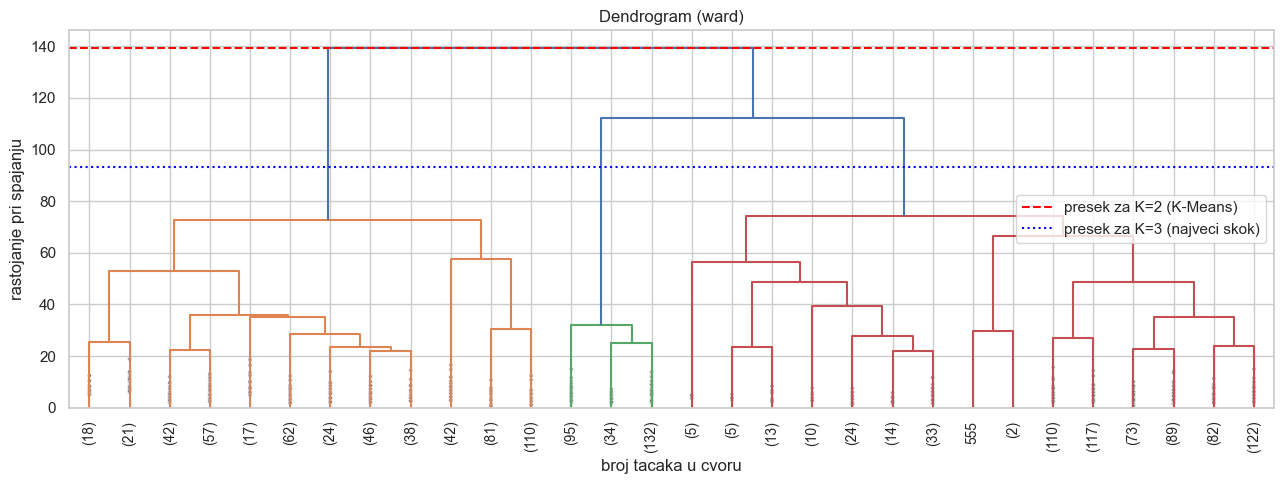

In [52]:
Z = linkage(A_all.values, method="ward")
n = Z.shape[0] + 1 # broj tacaka
heights = Z[:,2] # rastojanja pri spajanju (duzine n-1)

# metod najveceg skoka: za k klastera presek je izmedju spajanja (n-k-1) i (n-k)
# a velicina skoka = heights[n-k] - heights[n-k-1] - biramo k sa najvecim skokom
K_MAX_DENDRO = 10
gap_rows = []
for k in range(2, K_MAX_DENDRO + 1):
    if n - k - 1 < 0:
        break
    gap = heights[n - k] - heights[n - k - 1]
    gap_rows.append({"K": k, "skok": round(gap, 3)})
gap_tbl = pd.DataFrame(gap_rows).set_index("K")
k_dendro = int(gap_tbl["skok"].idxmax())
print("Najveci skok u dendogramu -> predlog K =", k_dendro,
      " | za poredjenje, K iz K-Means/silueta =", K)
display(gap_tbl.T)

# visine preseka za broj klastera iz dendrograma i kmeans
cut_dendro = (heights[n - k_dendro] + heights[n - k_dendro - 1]) / 2
cut_kmeans = Z[-(K-1), 2]

plt.figure(figsize=(13, 5))
dendrogram(Z, truncate_mode="lastp", p=30, leaf_rotation=90., show_contracted=True)
plt.axhline(y=cut_kmeans, color="red", ls="--", label=f"presek za K={K} (K-Means)")
plt.axhline(y=cut_dendro, color="blue", ls=":", label=f"presek za K={k_dendro} (najveci skok)")
plt.title("Dendrogram (ward)")
plt.xlabel("broj tacaka u cvoru")
plt.ylabel("rastojanje pri spajanju")
plt.legend()
plt.tight_layout()
plt.show()


### Poredjenje veza

Za svaku vezu treniramo model sa istim brojem klastera (radi postenog poredjenja sa ostalim algoritmima), pa racunamo siluetu, CH i DB, ali i velicine dobijenih klastera.

Kod veza single i average silueta ume da bude visoka iz pogresnog razloga, odnosno usled efekta ulancavanja algoritam izdvoji jednu ili nekoliko udaljenih tacaka u zaseban klaster, a sav ostatak ostavi u jednom ogromnom klasteru (npr. 1500+ tacaka u jednom i 2 tacke u drugom klasteru). Zato ne biramo vezu prosto po najvisoj silueti i biramo najbolju vezu medju nedegenerisanim.

In [54]:
linkages = ["single", "complete", "average", "ward"]
rows = []
agg_labels = {}
# klaster sa manje od max(3, 2% tacaka) tretiramo kao degenerisan
min_valid = max(3, int(0.02 * len(A_all)))
for lk in linkages:
    ac = AgglomerativeClustering(n_clusters=K, linkage=lk)
    lab = ac.fit_predict(A_all.values)
    agg_labels[lk] = lab
    sizes = np.bincount(lab)
    rows.append({
        "veza": lk,
        "silueta": round(silhouette_score(A_all.values, lab), 4),
        "CH": round(calinski_harabasz_score(A_all.values, lab), 1),
        "DB": round(davies_bouldin_score(A_all.values, lab), 4),
        "min_klaster": int(sizes.min()),
        "degenerisano": bool(sizes.min() < min_valid)
    })
cmp_link = pd.DataFrame(rows).set_index("veza")
display(cmp_link)

# najbolju vezu biramo po silueti ali samo medju nedegenerisanim podelama
print(f"Prag nedegenerisanosti - najmanji klaster < {min_valid} tacaka")
valid = cmp_link[~cmp_link["degenerisano"]]
if len(valid) > 0:
    best_link = valid["silueta"].idxmax()
    print("Najbolja (nedegenerisana) veza po silueti:", best_link)
    degen = cmp_link.index[cmp_link["degenerisano"]].tolist()
    if degen:
        print("Odbacene kao degenerisane:", ", ".join(degen))
else:
    best_link = "ward"
    print("Sve veze daju degeneriasnu podelu pa biramo ward kao najotpotniju metodu")

,silueta,CH,DB,min_klaster,degenerisano
veza,,,,,
single,0.8111,47.5,0.1320,1,True
complete,0.8111,47.5,0.1320,1,True
average,0.8111,47.5,0.1320,1,True
ward,0.1857,306.0,1.9395,558,False


Prag nedegenerisanosti - najmanji klaster < 30 tacaka
Najbolja (nedegenerisana) veza po silueti: ward
Odbacene kao degenerisane: single, complete, average


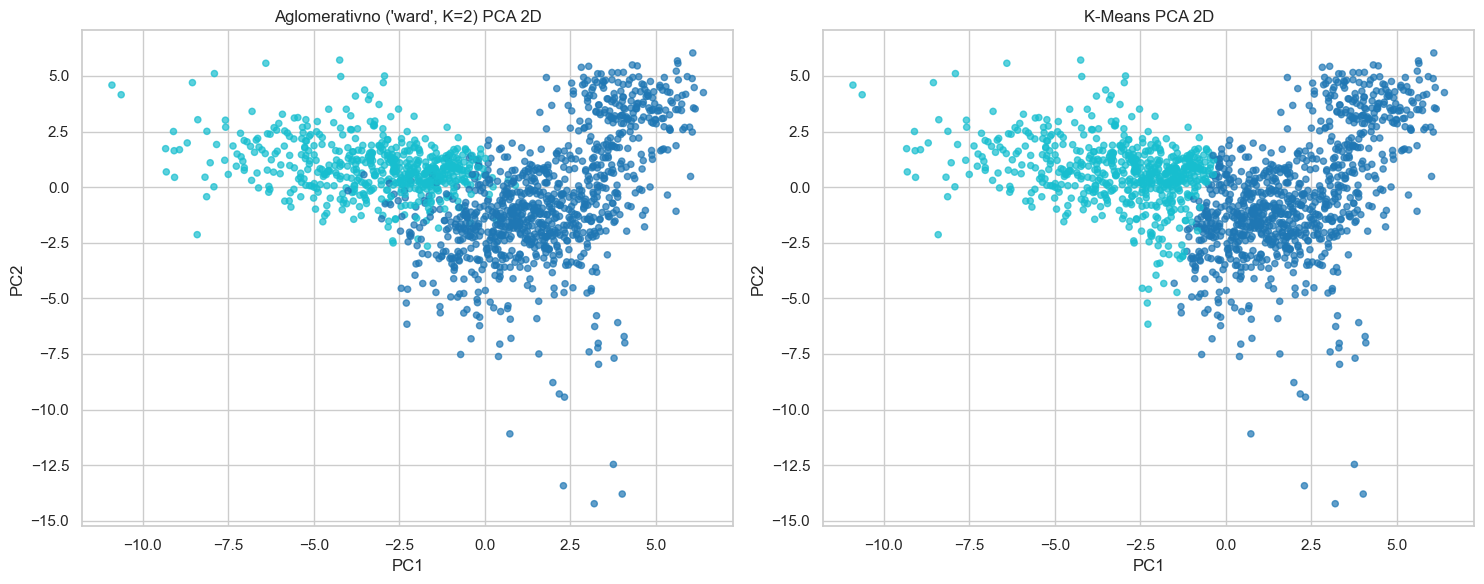

Slaganje aglomerativnog i K-Means (ARI): 0.7762


In [55]:
# vizuelizacija
best_labels = agg_labels[best_link]
team_season["cluster_agglo"] = best_labels

fig, ax = plt.subplots(1, 2, figsize=(15, 6))
ax[0].scatter(X_pca3[:,0], X_pca3[:,1], c=best_labels, cmap="tab10", s=20, alpha=.7)
ax[0].set_title(f"Aglomerativno ('{best_link}', K={K}) PCA 2D")
ax[0].set_xlabel("PC1")
ax[0].set_ylabel("PC2")
ax[1].scatter(X_pca3[:,0], X_pca3[:,1], c=km_labels, cmap="tab10", s=20, alpha=.7)
ax[1].set_title("K-Means PCA 2D")
ax[1].set_xlabel("PC1")
ax[1].set_ylabel("PC2")
plt.tight_layout()
plt.show()

print("Slaganje aglomerativnog i K-Means (ARI):", round(adjusted_rand_score(km_labels, best_labels), 4))


## Bisecting K-Means

Bisecting K-Means je divizivni (top-down) hijerarhijski pristup:

- svi podaci su u jednom klasteru;
- klaster se deli na dva pomoću običnog K-Means (K=2);
- bira se „najgori" klaster (npr. sa najvećim SSE) i dalje deli;
- postupak se ponavlja dok se ne dobije željeni broj klastera.


Bisecting K-Means (K=2) - velicine klastera:
0    921
1    598
Name: count, dtype: int64

Silueta: 0.1963 | CH: 332.0 | DB: 1.8892


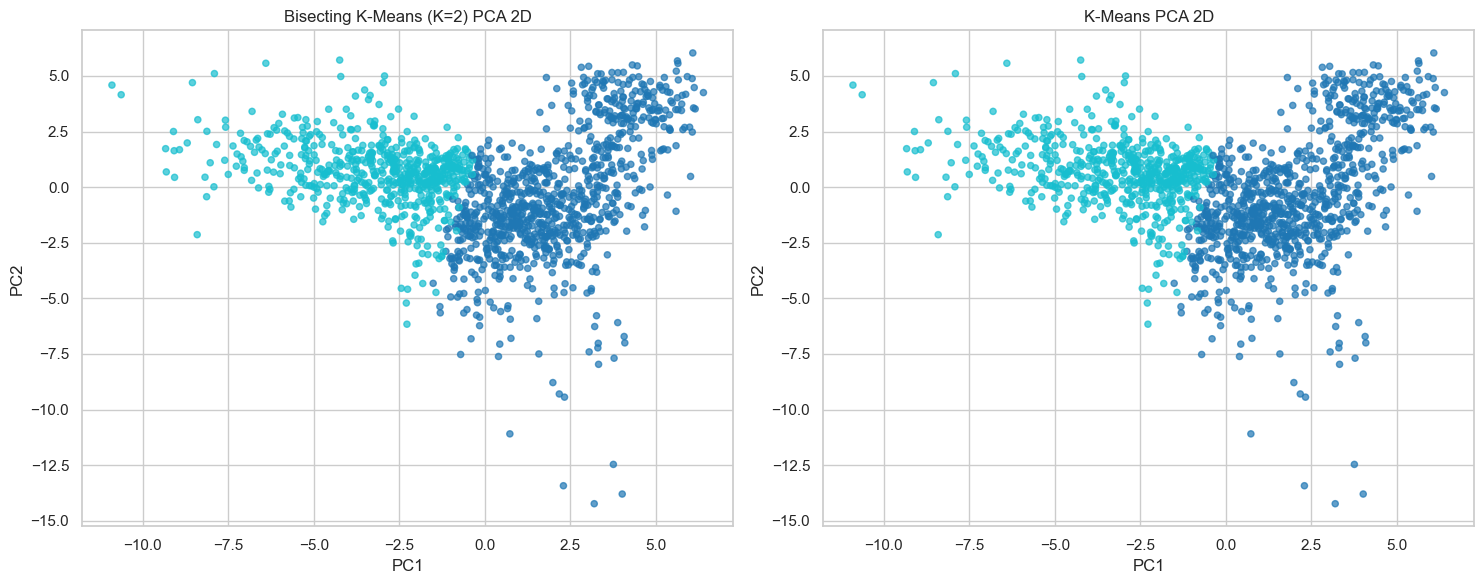

Slaganje Bisecting i K-Means (ARI): 1.0


In [56]:
bkm = BisectingKMeans(n_clusters=K, init="k-means++", n_init=10, random_state=RANDOM_STATE, algorithm="lloyd")
bkm_labels = bkm.fit_predict(A_all.values)
team_season["cluster_bisecting"] = bkm_labels

print(f"Bisecting K-Means (K={K}) - velicine klastera:")
print(pd.Series(bkm_labels).value_counts().sort_index())
print("\nSilueta:", round(silhouette_score(A_all.values, bkm_labels), 4),
      "| CH:", round(calinski_harabasz_score(A_all.values, bkm_labels), 1),
      "| DB:", round(davies_bouldin_score(A_all.values, bkm_labels), 4))

fig, ax = plt.subplots(1, 2, figsize=(15, 6))
ax[0].scatter(X_pca3[:,0], X_pca3[:,1], c=bkm_labels, cmap="tab10", s=20, alpha=.7)
ax[0].set_title(f"Bisecting K-Means (K={K}) PCA 2D")
ax[0].set_xlabel("PC1")
ax[0].set_ylabel("PC2")
ax[1].scatter(X_pca3[:,0], X_pca3[:,1], c=km_labels, cmap="tab10", s=20, alpha=.7)
ax[1].set_title("K-Means PCA 2D")
ax[1].set_xlabel("PC1")
ax[1].set_ylabel("PC2")
plt.tight_layout()
plt.show()
print("Slaganje Bisecting i K-Means (ARI):", round(adjusted_rand_score(km_labels, bkm_labels), 4))


In [58]:
# Poredjenje modela: svi atributi i redukovani skupovi
def eval_label(Xm, lab):
    return (silhouette_score(Xm, lab),
            calinski_harabasz_score(Xm, lab),
            davies_bouldin_score(Xm, lab))

def run_algo(name, Xm):
    if name == "K-Means":
        m = KMeans(n_clusters=K, init="k-means++", n_init=30, random_state=RANDOM_STATE)
    elif name == "Aglo-ward":
        m = AgglomerativeClustering(n_clusters=K, linkage="ward")
    elif name == "Bisecting":
        m = BisectingKMeans(n_clusters=K, init="k-means++", n_init=10, random_state=RANDOM_STATE)
    else:
        raise ValueError(f"Unknown algorithm: {name}")
    return m.fit_predict(Xm)

records = []
for set_name, M in feature_sets.items():
    Xm = M.values
    for algo in ["K-Means", "Aglo-ward", "Bisecting"]:
        lab = run_algo(algo, Xm)
        s, c, d = eval_label(Xm, lab)
        records.append({"skup_atributa": set_name, "algoritam": algo, "silueta": round(s, 4), "CH": round(c, 1), "DB": round(d, 4)})

comparison = pd.DataFrame(records)
display(comparison.pivot(index="skup_atributa", columns="algoritam", values="silueta")
        .rename_axis(columns="silueta ->"))
display(comparison)

silueta ->,Aglo-ward,Bisecting,K-Means
skup_atributa,,,
A: svi atributi,0.1857,0.1963,0.1963
B: ofanzivni,0.1614,0.1900,0.1900
C: efikasnost,0.2569,0.3005,0.2999
D: PCA(>=90%),0.1887,0.2116,0.2116


,skup_atributa,algoritam,silueta,CH,DB
0,A: svi atributi,K-Means,0.1963,332.0,1.8892
1,A: svi atributi,Aglo-ward,0.1857,306.0,1.9395
2,A: svi atributi,Bisecting,0.1963,332.0,1.8892
3,B: ofanzivni,K-Means,0.1900,328.8,1.9071
4,B: ofanzivni,Aglo-ward,0.1614,284.2,2.0662
5,B: ofanzivni,Bisecting,0.1900,328.8,1.9071
6,C: efikasnost,K-Means,0.2999,358.8,1.4154
7,C: efikasnost,Aglo-ward,0.2569,326.2,1.5959
8,C: efikasnost,Bisecting,0.3005,358.8,1.4089
9,D: PCA(>=90%),K-Means,0.2116,374.2,1.7665


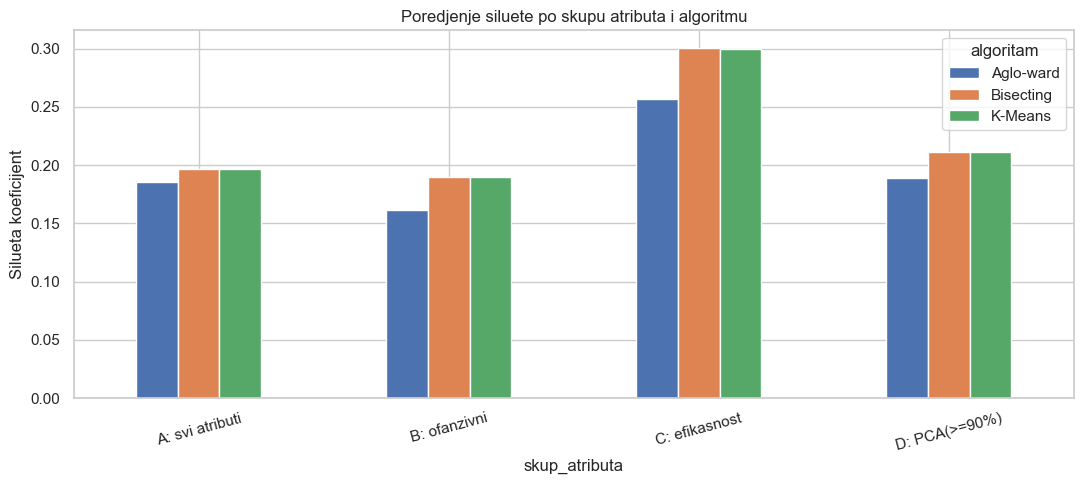

In [59]:
piv = comparison.pivot(index="skup_atributa", columns="algoritam", values="silueta")
ax = piv.plot(kind="bar", figsize=(11, 5))
ax.set_ylabel("Silueta koeficijent")
ax.set_title("Poredjenje siluete po skupu atributa i algoritmu")
plt.xticks(rotation=15)
plt.legend(title="algoritam")
plt.tight_layout()
plt.show()